In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("cuda is available")
else:
    print("cuda is NOT available")

import numpy as np
from tqdm import tqdm
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
import time
import copy
from moving_average import moving_average_1d

from nn_functions import surrogate

import sys
sys.path.append('../1_model')
from TiDE import TideModule, quantile_loss  


cuda is available


In [2]:
import torch
import pickle

# Load model
with open('TiDE_params_single_track_square_MV_temp_depth_less_cov_0915_w50_p50.pkl', 'rb') as file:
    nominal_params = pickle.load(file)

TiDE = nominal_params['model'].to(device)
total_params = sum(p.numel() for p in TiDE.parameters())


In [3]:
import numpy as np
import pandas as pd
from typing import Optional, Tuple
import sys

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

from pickle import dump
from sklearn.preprocessing import MinMaxScaler
import time
from tqdm import tqdm

import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import os

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("cuda is available")
else:
    print("cuda is NOT available")


import shutil
import warnings
import pickle

warnings.filterwarnings("ignore")
import logging

logging.disable(logging.CRITICAL)

from nn_functions import surrogate
from moving_average import moving_average_1d
import copy
from GAMMA_obj_temp_depth import GAMMA_obj


cuda is available


In [4]:
from policy import PolicyNN
model = PolicyNN(
    past_input_dim=6,
    future_input_dim=6,
    output_dim=1,
    p=50,
    window=50,
    hidden_dim=1024,
    n_layers=3,
    dropout_p=0.1
).to(device)

model.load_state_dict(torch.load("/home/ftk3187/github/DPC_research/02_DED/4_policy_0725/trainresults/policy_model_discreteshift_3L_1024H_s1_c3_case21.pth", map_location="cpu"))
model.eval()



PolicyNN(
  (input_layer): Linear(in_features=600, out_features=1024, bias=True)
  (input_ln): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (hidden_layers): ModuleList(
    (0): Linear(in_features=1024, out_features=1024, bias=True)
  )
  (norm_layers): ModuleList(
    (0): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  )
  (output_layer): Linear(in_features=1024, out_features=50, bias=True)
)

In [5]:
P = 50
window = 50

df_one_print = pd.read_csv('single_track_ref.csv')

loc_X_list = df_one_print["X"].to_numpy().reshape(-1,1)
loc_Y_list = df_one_print["Y"].to_numpy().reshape(-1,1)
loc_Z_list = df_one_print["Z"].to_numpy().reshape(-1,1)
dist_X_list = df_one_print["Dist_to_nearest_X"].to_numpy().reshape(-1,1)
dist_Y_list = df_one_print["Dist_to_nearest_Y"].to_numpy().reshape(-1,1)
scan_spd_list = df_one_print["scanning_speed"].to_numpy().reshape(-1,1)

# laser on/off indicator
laser_on_off = df_one_print["laser_power_number"].to_numpy().reshape(-1,1)

# laser power
laser_power_ref = torch.tensor(df_one_print["Laser_power"].to_numpy().reshape(-1,1),dtype=torch.float32)
laser_power_past = laser_power_ref[:window]

# fix_covariates = torch.tensor(np.concatenate((loc_X_list,loc_Y_list,loc_Z_list,dist_X_list,dist_Y_list,scan_spd_list, laser_on_off),axis=1),dtype=torch.float32)
fix_covariates = torch.tensor(np.concatenate((loc_Z_list,dist_X_list,dist_Y_list),axis=1),dtype=torch.float32)

# temporary ref
# apply moving average for mp temp
mp_temp_raw = df_one_print["melt_pool_temperature"].to_numpy()
mp_temp_mv = moving_average_1d(mp_temp_raw,4)
mp_temp = copy.deepcopy(mp_temp_raw)
mp_temp[1:-2] = mp_temp_mv
mp_temp = mp_temp

mp_temp_ref = torch.tensor(mp_temp,dtype=torch.float32)

In [6]:
print("laser_power_ref shape:", laser_power_ref.size())
print("laser_power_ref min:", torch.min(laser_power_ref).item())
print("laser_power_ref max:", torch.max(laser_power_ref).item())

print("fix_covariates shape:", fix_covariates.size())

col_min = torch.min(fix_covariates, dim=0).values
col_max = torch.max(fix_covariates, dim=0).values

print("fix_covariates column-wise min:", col_min.cpu().numpy())
print("fix_covariates column-wise max:", col_max.cpu().numpy())

nan_indices = torch.nonzero(torch.isnan(mp_temp_ref), as_tuple=True)[0]
print("NaN indices:", nan_indices)

valid_values = mp_temp_ref[~torch.isnan(mp_temp_ref)]

print("mp_temp_ref (valid) min:", valid_values.min().item())
print("mp_temp_ref (valid) max:", valid_values.max().item())



laser_power_ref shape: torch.Size([6295, 1])
laser_power_ref min: 531.5235595703125
laser_power_ref max: 600.7783203125
fix_covariates shape: torch.Size([6295, 3])
fix_covariates column-wise min: [0.   0.75 0.75]
fix_covariates column-wise max: [ 7.5 20.  20. ]
NaN indices: tensor([6292, 6294])
mp_temp_ref (valid) min: 436.1014099121094
mp_temp_ref (valid) max: 3834.751220703125


In [7]:
import torch

# values from user
x_min = torch.tensor([[0.0, 0.75, 0.75, 504.26]], dtype=torch.float32).to(device)
x_max = torch.tensor([[7.5, 20.0, 20.0, 732.298]], dtype=torch.float32).to(device)

y_min = torch.tensor([[436.608, -0.559]], dtype=torch.float32).to(device)
y_max = torch.tensor([[4509.855, 0.551]], dtype=torch.float32).to(device)


In [8]:
def normalize_x(x, dim_id):
    x_min_selected = x_min[0, dim_id]
    x_max_selected = x_max[0, dim_id]
    return 2 * (x - x_min_selected) / (x_max_selected - x_min_selected) - 1

def inverse_normalize_x(x_norm, dim_id):
    x_min_selected = x_min[0, dim_id]
    x_max_selected = x_max[0, dim_id]
    return 0.5 * (x_norm + 1) * (x_max_selected - x_min_selected) + x_min_selected

def normalize_y(y, dim_id):
    y_min_selected = y_min[0, dim_id]
    y_max_selected = y_max[0, dim_id]
    return 2 * (y - y_min_selected) / (y_max_selected - y_min_selected) - 1

def inverse_normalize_y(y_norm, dim_id):
    y_min_selected = y_min[0, dim_id]
    y_max_selected = y_max[0, dim_id]
    return 0.5 * (y_norm + 1) * (y_max_selected - y_min_selected) + y_min_selected


In [9]:
def run_one_step_policy(GAMMA_obj, policy_model, P, window):
    # Reference trajectory for temperature (original scale)
    mp_temp_ref = GAMMA_obj.ref[GAMMA_obj.MPC_counter:GAMMA_obj.MPC_counter + P]
    mp_temp_ref_t = torch.as_tensor(mp_temp_ref, dtype=torch.float32, device=device).reshape(1, P, 1)

    # Past input (original scale)
    mp_temp_past_t = GAMMA_obj.x_past.T.unsqueeze(0).to(device)      # [1, 50, 2]
    laser_past_t = GAMMA_obj.u_past.view(1, -1, 1).to(device)        # [1, 50, 1]
    fix_cov_past = GAMMA_obj.fix_cov_all[GAMMA_obj.MPC_counter - window:GAMMA_obj.MPC_counter, :]
    fix_cov_past_t = torch.as_tensor(fix_cov_past, dtype=torch.float32, device=device).unsqueeze(0)  # [1, 50, 3]

    # Normalize
    fix_cov_past_s = normalize_x(fix_cov_past_t, dim_id=[0, 1, 2])
    laser_past_s = normalize_x(laser_past_t, dim_id=[3])
    mp_temp_past_s = normalize_y(mp_temp_past_t, dim_id=[0, 1])

    policy_in_past = torch.cat((fix_cov_past_s, laser_past_s, mp_temp_past_s), dim=2)  # [1, 50, 6]

    # Future covariates
    fix_cov_future = GAMMA_obj.fix_cov_all[GAMMA_obj.MPC_counter:GAMMA_obj.MPC_counter + P, :]
    fix_cov_future_t = torch.as_tensor(fix_cov_future, dtype=torch.float32, device=device).unsqueeze(0)
    fix_cov_future_s = normalize_x(fix_cov_future_t, dim_id=[0, 1, 2])
    mp_temp_ref_s = normalize_y(mp_temp_ref_t, dim_id=[0])[:, :, 0].unsqueeze(-1)

    depth_lower_const = 0.1423
    depth_upper_const = 0.4126
    y_const_s = torch.tensor([[depth_lower_const, depth_upper_const]] * P, dtype=torch.float32, device=device).reshape(1, P, 2)

    policy_in_future = torch.cat((fix_cov_future_s, mp_temp_ref_s, y_const_s), dim=2)  # [1, P, 6]

    # Policy inference
    u_pred = policy_model((policy_in_past, policy_in_future))
    u_first = u_pred[0, 0]
    u_applied = float(inverse_normalize_x(u_first, dim_id=[3]))

    # Simulate one step with GAMMA
    x_current, depth_current = GAMMA_obj.run_sim_interval(u_applied)

    # Update past sequence
    GAMMA_obj.x_past[:, :-1] = GAMMA_obj.x_past[:, 1:]
    GAMMA_obj.x_past[0, -1] = x_current
    GAMMA_obj.x_past[1, -1] = depth_current

    GAMMA_obj.u_past[:-1] = GAMMA_obj.u_past[1:].clone()
    GAMMA_obj.u_past[-1] = u_applied

    # Save state
    GAMMA_obj.x_hat_current = torch.tensor([x_current, depth_current], device=device)
    GAMMA_obj.x_sys_current = torch.tensor([[x_current], [depth_current]], device=device)
    GAMMA_obj.MPC_counter += 1

    # Save trace (device matched)
    new_state = torch.tensor([[x_current, depth_current]], device=GAMMA_obj.x_past_save.device)
    GAMMA_obj.x_past_save = torch.cat((GAMMA_obj.x_past_save, new_state), dim=0)

    new_u = torch.tensor([[u_applied]], device=GAMMA_obj.u_past_save.device)
    GAMMA_obj.u_past_save = torch.cat((GAMMA_obj.u_past_save, new_u), dim=0)

    return u_pred  # ⬅️ 이후 TiDE 예측용으로 전체 제어 시퀀스를 넘겨줄 수 있게 반환


In [10]:
## timing

import time
import numpy as np
import torch

# ─────────────────────────────────────────────────────────
# run_one_step_policy: 정책 추론 시간(ms) 로깅 옵션 추가
# ─────────────────────────────────────────────────────────
def run_one_step_policy(GAMMA_obj, policy_model, P, window, policy_time_log=None):
    # Reference trajectory for temperature (original scale)
    mp_temp_ref = GAMMA_obj.ref[GAMMA_obj.MPC_counter:GAMMA_obj.MPC_counter + P]
    mp_temp_ref_t = torch.as_tensor(mp_temp_ref, dtype=torch.float32, device=device).reshape(1, P, 1)

    # Past input (original scale)
    mp_temp_past_t = GAMMA_obj.x_past.T.unsqueeze(0).to(device)      # [1, 50, 2]
    laser_past_t   = GAMMA_obj.u_past.view(1, -1, 1).to(device)      # [1, 50, 1]
    fix_cov_past   = GAMMA_obj.fix_cov_all[GAMMA_obj.MPC_counter - window:GAMMA_obj.MPC_counter, :]
    fix_cov_past_t = torch.as_tensor(fix_cov_past, dtype=torch.float32, device=device).unsqueeze(0)  # [1, 50, 3]

    # Normalize
    fix_cov_past_s = normalize_x(fix_cov_past_t, dim_id=[0, 1, 2])
    laser_past_s   = normalize_x(laser_past_t,   dim_id=[3])
    mp_temp_past_s = normalize_y(mp_temp_past_t, dim_id=[0, 1])
    policy_in_past = torch.cat((fix_cov_past_s, laser_past_s, mp_temp_past_s), dim=2)  # [1, 50, 6]

    # Future covariates
    fix_cov_future   = GAMMA_obj.fix_cov_all[GAMMA_obj.MPC_counter:GAMMA_obj.MPC_counter + P, :]
    fix_cov_future_t = torch.as_tensor(fix_cov_future, dtype=torch.float32, device=device).unsqueeze(0)
    fix_cov_future_s = normalize_x(fix_cov_future_t, dim_id=[0, 1, 2])
    mp_temp_ref_s    = normalize_y(mp_temp_ref_t, dim_id=[0])[:, :, 0].unsqueeze(-1)

    depth_lower_const = 0.1423
    depth_upper_const = 0.4126
    y_const_s = torch.tensor([[depth_lower_const, depth_upper_const]] * P,
                             dtype=torch.float32, device=device).reshape(1, P, 2)
    policy_in_future = torch.cat((fix_cov_future_s, mp_temp_ref_s, y_const_s), dim=2)  # [1, P, 6]

    # ── Policy inference (타이밍 측정 구간) ──────────────────────────
    if device.type == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad():
        u_pred = policy_model((policy_in_past, policy_in_future))
        # GPU 비동기 완결 보장
        if device.type == "cuda":
            torch.cuda.synchronize()
    dt_ms = (time.perf_counter() - t0) * 1e3
    if policy_time_log is not None:
        policy_time_log.append(dt_ms)
    # ────────────────────────────────────────────────────────────────

    # 첫 스텝 제어 적용
    u_first   = u_pred[0, 0]
    u_applied = float(inverse_normalize_x(u_first, dim_id=[3]))

    # Simulate one step with GAMMA
    x_current, depth_current = GAMMA_obj.run_sim_interval(u_applied)

    # Update past sequence
    GAMMA_obj.x_past[:, :-1] = GAMMA_obj.x_past[:, 1:]
    GAMMA_obj.x_past[0, -1] = x_current
    GAMMA_obj.x_past[1, -1] = depth_current

    GAMMA_obj.u_past[:-1] = GAMMA_obj.u_past[1:].clone()
    GAMMA_obj.u_past[-1]  = u_applied

    # Save state
    GAMMA_obj.x_hat_current = torch.tensor([x_current, depth_current], device=device)
    GAMMA_obj.x_sys_current = torch.tensor([[x_current], [depth_current]], device=device)
    GAMMA_obj.MPC_counter  += 1

    # Save trace (device matched)
    new_state = torch.tensor([[x_current, depth_current]], device=GAMMA_obj.x_past_save.device)
    GAMMA_obj.x_past_save = torch.cat((GAMMA_obj.x_past_save, new_state), dim=0)

    new_u = torch.tensor([[u_applied]], device=GAMMA_obj.u_past_save.device)
    GAMMA_obj.u_past_save = torch.cat((GAMMA_obj.u_past_save, new_u), dim=0)

    return u_pred


In [11]:
import copy
import torch

def simulate_policy_horizon_for_visualization(GAMMA_obj, TiDE, P, window, u_pred):
    """
    Args:
        u_pred: [1, 50, 1] - normalized policy output

    Returns:
        - tide_temp_pred: [50], inverse normalized
        - tide_depth_pred: [50], inverse normalized
        - u_seq: [50], inverse normalized
    """
    # ── 1. Policy Input (normalized) ──────────────────────
    mp_temp_past_t = GAMMA_obj.x_past.T.unsqueeze(0).to(device)  # [1, 50, 2]
    laser_past_t = GAMMA_obj.u_past.view(1, -1, 1).to(device)     # [1, 50, 1]

    fix_cov_past = GAMMA_obj.fix_cov_all[GAMMA_obj.MPC_counter - window:GAMMA_obj.MPC_counter, :]
    fix_cov_future = GAMMA_obj.fix_cov_all[GAMMA_obj.MPC_counter:GAMMA_obj.MPC_counter + P, :]

    fix_cov_past_t = torch.tensor(fix_cov_past, dtype=torch.float32, device=device).unsqueeze(0)
    fix_cov_future_t = torch.tensor(fix_cov_future, dtype=torch.float32, device=device).unsqueeze(0)

    fix_cov_past_s = normalize_x(fix_cov_past_t, dim_id=[0, 1, 2])
    fix_cov_future_s = normalize_x(fix_cov_future_t, dim_id=[0, 1, 2])
    laser_past_s = normalize_x(laser_past_t, dim_id=[3])
    mp_temp_past_s = normalize_y(mp_temp_past_t, dim_id=[0, 1])

    # ── 2. Inverse normalize u_pred → u_seq ───────────────
    u_seq = inverse_normalize_x(u_pred[0], dim_id=[3])  # [50, 1]

    # ── 3. TiDE prediction input construction ─────────────
    past_cov = torch.cat((mp_temp_past_s, fix_cov_past_s, laser_past_s), dim=2)     # [1, 50, dim]
    future_cov = torch.cat((fix_cov_future_s, u_pred.to(device)), dim=2)  # [1, 50, dim]

    with torch.no_grad():
        tide_out = TiDE((past_cov, future_cov, None))  # [1, 50, quantile, 2]
        tide_out_med = tide_out[:, :, :, 1].squeeze(0)  # [50, 2]
        tide_temp_pred = inverse_normalize_y(tide_out_med[:, 0], dim_id=[0])
        tide_depth_pred = inverse_normalize_y(tide_out_med[:, 1], dim_id=[1])

    return (
        tide_temp_pred.detach().cpu().numpy(),   # [50]
        tide_depth_pred.detach().cpu().numpy(),  # [50]
        u_seq.detach().cpu().numpy()             # [50, 1]
    )


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_fig(MPC_GAMMA, N_step):
    plt.figure(figsize=[8, 6])

    # ── 1. Melt Pool Temperature ───────
    plt.subplot(3, 1, 1)
    plt.plot(MPC_GAMMA.x_past_save[:N_step, 0].detach().cpu().numpy(), label="GAMMA simulation")
    plt.plot(MPC_GAMMA.ref[:N_step].detach().cpu().numpy(), label="Reference")
    plt.xlabel("Time step")
    plt.ylabel("Melt Pool Temp (K)")
    plt.legend()

    # ── 2. Melt Pool Depth ─────────────
    plt.subplot(3, 1, 2)
    plt.plot(MPC_GAMMA.x_past_save[:N_step, 1].detach().cpu().numpy(), label="Depth")
    plt.plot(np.linspace(0, N_step, N_step), 0.225 * np.ones(N_step), 'r--', label="Upper Bound")
    plt.plot(np.linspace(0, N_step, N_step), 0.075 * np.ones(N_step), 'b--', label="Lower Bound")
    plt.xlabel("Time step")
    plt.ylabel("Depth (mm)")
    plt.legend()

    # ── 3. Laser Power ─────────────────
    plt.subplot(3, 1, 3)
    plt.plot(MPC_GAMMA.u_past_save[:N_step].detach().cpu().numpy(), label="Laser Power")
    plt.xlabel("Time step")
    plt.ylabel("Laser Power (W)")
    plt.legend()

    plt.tight_layout()
    plt.show()


In [13]:
def plot_fig_with_tide(
    MPC_GAMMA, N_step,
    tide_temp_all, tide_depth_all, u_seq_all,
    start_t=3000, output_dir="tide_prediction_plots", laser_num=None
):
    if output_dir and not os.path.exists(output_dir):
        os.makedirs(output_dir)

    plt.figure(figsize=[8, 6])

    # ── 1. Melt Pool Temperature ──────────────────────────────
    plt.subplot(3, 1, 1)
    plt.plot(MPC_GAMMA.x_past_save[:N_step, 0].detach().cpu().numpy(), label="GAMMA simulation")
    plt.plot(MPC_GAMMA.ref[:N_step].detach().cpu().numpy(), label="Reference")

    for i, tide_temp in enumerate(tide_temp_all):
        t = start_t + i
        plt.plot(np.arange(t, t + len(tide_temp)), tide_temp, color='tab:green', linestyle='--',
                 label="TiDE prediction" if i == 0 else None)

    xlim_start = max(0, start_t + P - 500)
    xlim_end = start_t + P
    plt.xlim(0, xlim_end)
    plt.xlabel("MPC time step (0.0355 sec/iteration)")
    plt.ylabel("Melt Pool Temperature (K)")
    plt.legend(loc="lower left")

    # ── 2. Melt Pool Depth ──────────────────────────────
    plt.subplot(3, 1, 2)
    plt.plot(MPC_GAMMA.x_past_save[:N_step, 1].detach().cpu().numpy(), label="GAMMA simulation")
    plt.plot(np.linspace(0, N_step, N_step), 0.225 * np.ones(N_step), 'r--', label="Upper Bound")
    plt.plot(np.linspace(0, N_step, N_step), 0.075 * np.ones(N_step), 'b--', label="Lower Bound")

    for i, tide_depth in enumerate(tide_depth_all):
        t = start_t + i
        plt.plot(np.arange(t, t + len(tide_depth)), tide_depth, color='tab:orange', linestyle='--',
                 label="TiDE prediction" if i == 0 else None)

    plt.xlim(0, xlim_end)
    plt.xlabel("MPC time step (0.0355 sec/iteration)")
    plt.ylabel("Melt Pool Depth (mm)")
    plt.legend(loc="lower left")

    # ── 3. Laser Power ──────────────────────────────
    plt.subplot(3, 1, 3)
    plt.plot(MPC_GAMMA.u_past_save[:N_step].detach().cpu().numpy(), label="Applied Laser Power")

    for i, u_seq in enumerate(u_seq_all):
        t = start_t + i
        plt.plot(np.arange(t, t + len(u_seq)), u_seq, color='tab:red', linestyle='--',
                 label="Policy Output" if i == 0 else None)

    plt.xlim(0, xlim_end)
    plt.xlabel("MPC time step (0.0355 sec/iteration)")
    plt.ylabel("Laser power (W)")
    plt.legend(loc="lower left")

    plt.tight_layout()

    # Save figure with laser_num if provided
    suffix = f"_laser_{laser_num}" if laser_num is not None else ""
    save_path = os.path.join(output_dir, f"tide_plot_step_{start_t}{suffix}.png")
    plt.savefig(save_path, dpi=200)
    plt.close()


In [ ]:
def plot_fig_with_tide(
    MPC_GAMMA, N_step,
    tide_temp_all, tide_depth_all, u_seq_all,
    start_t=3000, output_dir="tide_prediction_plots", laser_num=None
):
    if output_dir and not os.path.exists(output_dir):
        os.makedirs(output_dir)

    plt.figure(figsize=[8, 6])
    
    # ── 1. Melt Pool Temperature ──────────────────────────────
    plt.subplot(3, 1, 1)
    plt.plot(MPC_GAMMA.ref[:N_step].detach().cpu().numpy(), label="Reference")
    plt.plot(MPC_GAMMA.x_past_save[:N_step, 0].detach().cpu().numpy(), label="GAMMA simulation")

    for i, tide_temp in enumerate(tide_temp_all):
        t = start_t + i
        plt.plot(np.arange(t, t + len(tide_temp)), tide_temp, color='tab:green', linestyle='--',
                label="TiDE prediction" if i == 0 else None)

    # 현재 위치 점 (검정)
    plt.scatter(start_t,
                MPC_GAMMA.x_past_save[start_t, 0].detach().cpu().numpy(),
                color='k', s=30, zorder=5)

    xlim_end = start_t + P
    plt.xlim(0, xlim_end)
    plt.xlabel("MPC time step")
    plt.ylabel("Melt Pool Temperature (K)")
    plt.legend(loc="lower left")

    # ── 2. Melt Pool Depth ──────────────────────────────
    plt.subplot(3, 1, 2)
    plt.plot(np.linspace(0, N_step, N_step), 0.225 * np.ones(N_step), 'r--', label="Upper Bound")
    plt.plot(np.linspace(0, N_step, N_step), 0.075 * np.ones(N_step), 'b--', label="lower Bound")
    plt.plot(MPC_GAMMA.x_past_save[:N_step, 1].detach().cpu().numpy(), label="GAMMA simulation")

    for i, tide_depth in enumerate(tide_depth_all):
        t = start_t + i
        plt.plot(np.arange(t, t + len(tide_depth)), tide_depth, color='tab:orange', linestyle='--',
                label="TiDE prediction" if i == 0 else None)

    # 현재 위치 점 (검정)
    plt.scatter(start_t,
                MPC_GAMMA.x_past_save[start_t, 1].detach().cpu().numpy(),
                color='k', s=30, zorder=5)

    plt.xlim(0, xlim_end)
    plt.xlabel("MPC time step")
    plt.ylabel("Melt Pool Depth (mm)")
    plt.legend(loc="lower left")

    # ── 3. Laser Power ──────────────────────────────
    plt.subplot(3, 1, 3)
    plt.plot(MPC_GAMMA.u_past_save[:N_step].detach().cpu().numpy(), label="Applied Laser Power")

    for i, u_seq in enumerate(u_seq_all):
        t = start_t + i
        plt.plot(np.arange(t, t + len(u_seq)), u_seq, color='tab:red', linestyle='--',
                label="Policy Output" if i == 0 else None)

    # 현재 위치 점 (검정)
    plt.scatter(start_t,
                MPC_GAMMA.u_past_save[start_t].detach().cpu().numpy(),
                color='k', s=30, zorder=5)

    plt.xlim(0, xlim_end)
    plt.xlabel("MPC time step")
    plt.ylabel("Laser power (W)")
    plt.legend(loc="lower left")
    plt.tight_layout()

    # Save figure with laser_num if provided
    suffix = f"_laser_{laser_num}" if laser_num is not None else ""
    save_path = os.path.join(output_dir, f"tide_plot_step_{start_t}{suffix}.png")
    plt.savefig(save_path, dpi=200)
    plt.close()




Laser 42:   0%|          | 0/6195 [00:00<?, ?it/s]

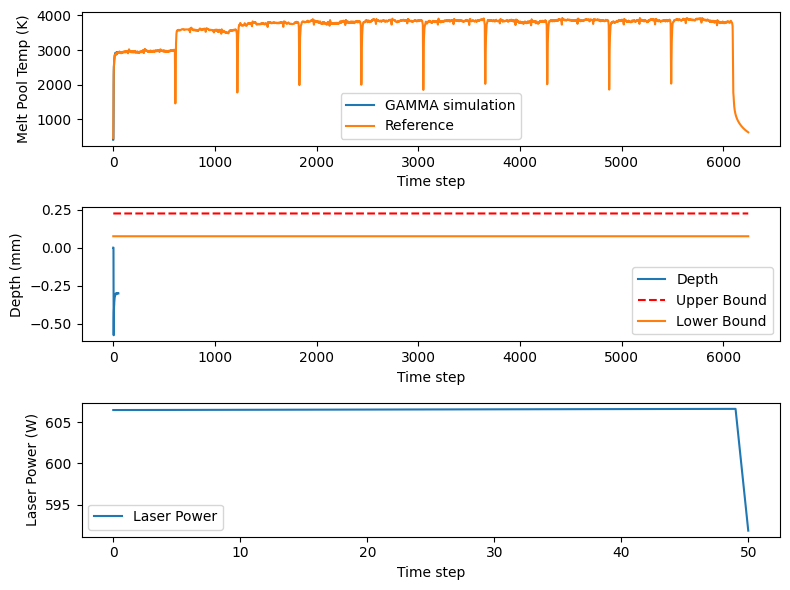

Laser 42:   2%|▏         | 100/6195 [00:13<12:32,  8.10it/s]

[Step 100] Mean so far: 0.77 ms | Last 100 mean: 0.77 ms


Laser 42:   3%|▎         | 200/6195 [00:27<12:20,  8.09it/s]

[Step 200] Mean so far: 0.58 ms | Last 100 mean: 0.39 ms


Laser 42:   5%|▍         | 300/6195 [00:41<12:12,  8.04it/s]

...

[Step 800] Mean so far: 0.42 ms | Last 100 mean: 0.36 ms


Laser 42:  15%|█▍        | 900/6195 [02:06<11:22,  7.76it/s]

[Step 900] Mean so far: 0.42 ms | Last 100 mean: 0.37 ms


Laser 42:  15%|█▍        | 914/6195 [02:08<12:23,  7.10it/s]


KeyboardInterrupt: 

In [15]:
import os
import pandas as pd
import numpy as np
import torch
import copy
from tqdm import tqdm

# ── Settings ─────────────────────────────
device = torch.device("cuda:0")
laser_num = 42  # 🔧 실행할 laser_power_number만 여기에 입력
plot_tide_range = (50, 3600) #6190
P = 50
window = 50
sim_interval = 5
init_runs = 50
solidus_temp = 1600
INPUT_DATA_DIR = "data"
SIM_DIR_NAME = "single_track_square"
BASE_LASER_FILE_DIR = "laser_power_profiles/csv"
CLOUD_TARGET_BASE_PATH = "result"

model_path = "/home/ftk3187/github/DPC_research/02_DED/4_policy_0725/trainresults/policy_model_discreteshift_3L_1024H_s1_c3_case21.pth"
save_dir = "/home/ftk3187/github/DPC_research/02_DED/4_policy_0725/simulation_outputs_case21_discrete shift"
os.makedirs(save_dir, exist_ok=True)

output_dir = "tide_prediction_plots"
os.makedirs(output_dir, exist_ok=True)

# ── Load model ───────────────────────────
model = PolicyNN(
    past_input_dim=6,
    future_input_dim=6,
    output_dim=1,
    p=P,
    window=window,
    hidden_dim=1024,
    n_layers=3,
    dropout_p=0.1
).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

# ── Load input CSV ───────────────────────
csv_path = f"/home/ftk3187/github/DPC_research/02_DED/4_policy_0725/split_by_laser_power_number/laser_power_number_{laser_num}.csv"
df = pd.read_csv(csv_path)

# ── GAMMA init ───────────────────────────
GAMMA_class = GAMMA_obj(INPUT_DATA_DIR, SIM_DIR_NAME, BASE_LASER_FILE_DIR,
                        CLOUD_TARGET_BASE_PATH, solidus_temp, window,
                        init_runs, sim_interval, laser_power_number=laser_num)

init_avg = GAMMA_class.run_initial_steps()
init_avg = torch.tensor(init_avg, dtype=torch.float32).to(device)[:, -window:]

# ── Prepare covariates & references ──────
loc_Z = df["Z"].to_numpy().reshape(-1, 1)
dist_X = df["Dist_to_nearest_X"].to_numpy().reshape(-1, 1)
dist_Y = df["Dist_to_nearest_Y"].to_numpy().reshape(-1, 1)
fix_covariates = torch.tensor(np.concatenate((loc_Z, dist_X, dist_Y), axis=1), dtype=torch.float32).to(device)

laser_power_ref = torch.tensor(df["Laser_power"].to_numpy().reshape(-1, 1), dtype=torch.float32).to(device)
laser_power_past = laser_power_ref[:window]

mp_temp_raw = df["melt_pool_temperature"].to_numpy()
mp_temp = copy.deepcopy(mp_temp_raw)
mp_temp[1:-2] = moving_average_1d(mp_temp_raw, 4)
mp_temp_ref = torch.tensor(mp_temp, dtype=torch.float32).to(device)

mp_depth_raw = df["melt_pool_depth"].to_numpy()
mp_depth = copy.deepcopy(mp_depth_raw)
mp_depth[1:-2] = moving_average_1d(mp_depth_raw, 4)
mp_depth_ref = torch.tensor(mp_depth, dtype=torch.float32).to(device)

# ── GAMMA state init ─────────────────────
GAMMA_class.ref = mp_temp_ref.clone()
GAMMA_class.fix_cov_all = fix_covariates.clone()
GAMMA_class.x_past = init_avg.clone()
GAMMA_class.u_past = laser_power_past.clone()
GAMMA_class.x_past_save = GAMMA_class.x_past.T.clone()
GAMMA_class.u_past_save = GAMMA_class.u_past.clone()
GAMMA_class.MPC_counter = window
GAMMA_class.x_hat_current = GAMMA_class.x_past[:, -1]
GAMMA_class.x_sys_current = GAMMA_class.x_past[:, -1].reshape(2, 1)

# ── Simulation loop ──────────────────────
N_step = len(mp_temp_ref) - P
tide_temp_all, tide_depth_all, u_seq_all = [], [], []
policy_time_log = []  # ⬅️ 추가: 추론 시간(ms) 누적 리스트

for i in tqdm(range(N_step - P), desc=f"Laser {laser_num}"):
    # 정책 실행 + 시간 로깅
    u_pred = run_one_step_policy(
        GAMMA_class, model, P=P, window=window,
        policy_time_log=policy_time_log
    )

    # 100 스텝마다 현재까지 평균 / 최근 100개 평균 출력
    if len(policy_time_log) % 100 == 0 and len(policy_time_log) > 0:
        times_np = np.array(policy_time_log, dtype=np.float64)
        overall_mean = times_np.mean()
        last100_mean = times_np[-100:].mean()
        tqdm.write(
            f"[Step {i+1}] "
            f"Mean so far: {overall_mean:.2f} ms | "
            f"Last 100 mean: {last100_mean:.2f} ms"
        )

    if plot_tide_range[0] <= i < plot_tide_range[1] and i % 20 == 0:
        tide_temp, tide_depth, u_seq = simulate_policy_horizon_for_visualization(
            GAMMA_obj=GAMMA_class, TiDE=TiDE, P=P, window=window, u_pred=u_pred
        )
        tide_temp_all.append(tide_temp)
        tide_depth_all.append(tide_depth)
        u_seq_all.append(u_seq.squeeze(-1))

        plot_fig_with_tide(
            MPC_GAMMA=GAMMA_class, N_step=N_step,
            tide_temp_all=[tide_temp], tide_depth_all=[tide_depth],
            u_seq_all=[u_seq_all[-1]], start_t=i+P, output_dir=output_dir
        )

    elif i % 300 == 0:
        plot_fig(GAMMA_class, N_step)


# ── Save outputs ─────────────────────────
x_save  = GAMMA_class.x_past_save.detach().cpu().numpy()
u_save  = GAMMA_class.u_past_save.detach().cpu().numpy()
ref_save = GAMMA_class.ref.detach().cpu().numpy()

pd.DataFrame(x_save).to_csv(os.path.join(save_dir, f"x_outputs_laser_{laser_num}.csv"), index=False)
pd.DataFrame(u_save).to_csv(os.path.join(save_dir, f"u_outputs_laser_{laser_num}.csv"), index=False)
pd.DataFrame(ref_save).to_csv(os.path.join(save_dir, f"ref_laser_{laser_num}.csv"), index=False)

# ── Save policy-time distribution (CSV + stats + histogram) ───────
import numpy as np, json, matplotlib.pyplot as plt

times = np.array(policy_time_log, dtype=np.float64)  # ms
pd.DataFrame({"step": np.arange(times.size), "policy_ms": times}) \
  .to_csv(os.path.join(save_dir, f"policy_times_laser_{laser_num}.csv"), index=False)

stats = {
    "count": int(times.size),
    "mean_ms": float(times.mean()) if times.size else None,
    "std_ms": float(times.std(ddof=1)) if times.size > 1 else 0.0,
    "min_ms": float(times.min()) if times.size else None,
    "p50_ms": float(np.percentile(times, 50)) if times.size else None,
    "p90_ms": float(np.percentile(times, 90)) if times.size else None,
    "p95_ms": float(np.percentile(times, 95)) if times.size else None,
    "p99_ms": float(np.percentile(times, 99)) if times.size else None,
    "max_ms": float(times.max()) if times.size else None,
    "throughput_steps_per_s@mean": (1000.0 / float(times.mean())) if times.size else None,
}
with open(os.path.join(save_dir, f"policy_time_stats_laser_{laser_num}.json"), "w") as f:
    json.dump(stats, f, indent=2)
print("[Policy-time stats]", stats)

plt.figure(figsize=(6,4))
plt.hist(times, bins="auto")
plt.xlabel("Policy inference time (ms)")
plt.ylabel("Count")
plt.title(f"Laser {laser_num} | mean={stats['mean_ms']:.2f} ms, p95={stats['p95_ms']:.2f} ms")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, f"policy_time_hist_laser_{laser_num}.png"), dpi=150)
plt.close()

print(f"✅ Completed and saved for laser_power_number {laser_num}")



In [ ]:
import os
import re
import imageio
from tqdm import tqdm

# ── 설정 ────────────────────────────────
folder_path = "/home/ftk3187/github/DPC_research/02_DED/4_policy_0725/tide_prediction_plots"
gif_path = os.path.join(folder_path, "tide_prediction.gif")
mp4_path = os.path.join(folder_path, "tide_prediction.mp4") 

# ── 파일 리스트 자동 수집 및 정렬 ────────
pattern = re.compile(r"tide_plot_step_(\d+)\.png")
files = []

for filename in os.listdir(folder_path):
    match = pattern.match(filename)
    if match:
        step = int(match.group(1))
        files.append((step, filename))

# step 기준 정렬
files.sort(key=lambda x: x[0])

# ── 프레임 리스트 생성 ─────────────────
frames = []
for step, filename in tqdm(files, desc="Creating GIF"):
    file_path = os.path.join(folder_path, filename)
    image = imageio.v2.imread(file_path)
    frames.append(image)

# ── GIF 및 MP4 저장 ─────────────────────
imageio.mimsave(gif_path, frames, duration=1.5)
imageio.mimsave(mp4_path, frames, fps=5)

print(f"✅ GIF 저장 완료: {gif_path}")
print(f"✅ MP4 저장 완료: {mp4_path}")


Creating GIF: 100%|██████████| 177/177 [00:05<00:00, 31.82it/s]


✅ GIF 저장 완료: /home/ftk3187/github/DPC_research/02_DED/4_policy_0725/tide_prediction_plots/tide_prediction.gif
✅ MP4 저장 완료: /home/ftk3187/github/DPC_research/02_DED/4_policy_0725/tide_prediction_plots/tide_prediction.mp4


In [ ]:
# ── After the loop ───────────────────────
times = np.array(policy_time_log, dtype=np.float64)  # ms

def plot_policy_time_hist(times_ms, save_dir, laser_num):
    import matplotlib.pyplot as plt
    import numpy as np
    import json, os
    import pandas as pd

    if times_ms.size == 0:
        print("No policy_time_log collected — skip plotting.")
        return

    # ms → s 변환
    times_s = times_ms / 1000.0

    # 기본 통계 (초 단위)
    mean_s = float(times_s.mean())
    stats = {
        "count": int(times_s.size),
        "mean_s": mean_s,
        "std_s": float(times_s.std(ddof=1)) if times_s.size > 1 else 0.0,
        "min_s": float(times_s.min()),
        "p50_s": float(np.percentile(times_s, 50)),
        "p90_s": float(np.percentile(times_s, 90)),
        "max_s": float(times_s.max()),
        "throughput_steps_per_s@mean": (1.0 / mean_s) if mean_s > 0 else None,
    }

    # CSV 저장 (초 단위)
    pd.DataFrame({"step": np.arange(times_s.size), "policy_s": times_s}) \
      .to_csv(os.path.join(save_dir, f"policy_times_laser_{laser_num}.csv"), index=False)
    with open(os.path.join(save_dir, f"policy_time_stats_laser_{laser_num}.json"), "w") as f:
        json.dump(stats, f, indent=2)
    print("[Policy-time stats]", stats)

    # 히스토그램 (초 단위)
    plt.figure(figsize=(5,3))
    plt.hist(times_s, bins="fd")
    plt.xlabel("Policy inference time (s)")
    plt.ylabel("Count")
    plt.title(f"Policy Inference Time")

    # 지표 라인 표시(p50, p90만)
    for q,label,style in [(50,"p50","--"), (90,"p90","--")]:
        v = np.percentile(times_s, q)
        #plt.axvline(v, linestyle=style, linewidth=1)
        ymax = plt.ylim()[1]
        plt.xlim(0, 0.001)
        #plt.text(v, ymax*0.95, f"{label}={v:.4f} s", rotation=90, va="top", ha="right")

    out_path = os.path.join(save_dir, f"Policy Inference Time.png")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.close()
    print(f"Saved histogram → {out_path}")

# 호출
plot_policy_time_hist(times, save_dir, laser_num)


[Policy-time stats] {'count': 6195, 'mean_s': 0.0003957605114187128, 'std_s': 0.0005626007851107546, 'min_s': 0.00033921748399734497, 'p50_s': 0.0003798641264438629, 'p90_s': 0.0004180245101451875, 'max_s': 0.04442640393972397, 'throughput_steps_per_s@mean': 2526.780644221486}
Saved histogram → /home/ftk3187/github/DPC_research/02_DED/4_policy_0725/simulation_outputs_case21_discrete shift/Policy Inference Time.png
